# Lifetime OWSA analysis | ages 1-100

The notebook displays reusable lifetime OWSA tables and figures. Core calculations live under `app.notebook.owsa`.

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

from app.notebook.owsa import OWSAReport
from app.notebook.psa import LIFETIME
from app.notebook.psa.presentation import render_table

report = OWSAReport.load(LIFETIME)
print(f"{report.horizon.label}: {report.df.height:,} OWSA rows")
print(f"WTP: {report.wtp:,.0f} IRR/QALY")

g++ not available, if using conda: `conda install gxx`


Lifetime horizon (ages 2–100): 94,000 OWSA rows
WTP: 18,000,000,000 IRR/QALY


In [ ]:
tables = report.tables()
for title, table in tables.items():
    display(Markdown(f"## {title}"))
    display(HTML(render_table(table)))

ranking = tables["OWSA sensitivity ranking"]
top = ranking.row(0, named=True)
changed = ranking.filter(ranking["decision_changes"]).height
display(
    Markdown(
        f"**Interpretation.** The most influential input by incremental NMB is **{top['label']}**. "
        f"The cost-effectiveness decision changes in {changed} of {ranking.height} one-way parameter analyses.\n\n"
        "**Conclusion.** Parameters that cross zero incremental NMB are decision-critical; parameters that only change the ICER magnitude but preserve the NMB sign do not change the economic conclusion at the selected WTP."
    )
)

## Parameter ranges

parameter,label,low,base,high
advanced_arthropathy_utility,Advanced Arthropathy Utility,0.720,0.740,0.770
end_stage_arthropathy_utility,End Stage Arthropathy Utility,0.482,0.720,0.740
factor_consumption_per_intracranial_hemorrhage_per_kg,Factor Consumption Per Intracranial Hemorrhage Per Kg,400.942,550.000,724.090
factor_consumption_per_joint_bleeding_per_kg,Factor Consumption Per Joint Bleeding Per Kg,43.516,60.000,78.861
factor_consumption_per_non_ich_major_bleeding_per_kg,Factor Consumption Per Non Ich Major Bleeding Per Kg,402.912,550.000,725.548
factor_consumption_per_spontaneous_bleeding_per_kg,Factor Consumption Per Spontaneous Bleeding Per Kg,87.821,120.000,157.845
gi_neck_bleeding_fraction,Gi Neck Bleeding Fraction,0.004,0.005,0.006
healthy_utility,Healthy Utility,0.844,0.940,0.984
ich_case_fatality,Ich Case Fatality,0.017,0.100,0.241
iliopsoas_bleeding_fraction,Iliopsoas Bleeding Fraction,0.001,0.003,0.005


## Base-case cost effectiveness

comparison,paired_iterations,delta_cost,delta_qaly,icer,delta_nmb,probability_cost_effective,wtp,cost_effective
lifetime prophylaxis bayesian vs lifetime on-demand bayesian,"1,000","846,438,342,513.800",9.803,"86,347,010,773.167","-669,988,804,436.877",0.004,"18,000,000,000.000",0


## OWSA sensitivity ranking

...

## Decision robustness

parameter,label,base_cost_effective,low_cost_effective,high_cost_effective,decision_changes,nmb_sensitivity
on_demand_bleeding_rate,On Demand Bleeding Rate,0,0,1,1,"876,121,191,244.154"
prophylaxis_background_factor_consumption_per_kg,Prophylaxis Background Factor Consumption Per Kg,0,0,0,0,"395,936,230,258.827"
prophylaxis_bleeding_rate,Prophylaxis Bleeding Rate,0,0,0,0,"156,797,758,223.685"
end_stage_arthropathy_utility,End Stage Arthropathy Utility,0,0,0,0,"138,925,477,603.312"
weight_factor,Body Weight Factor,0,0,0,0,"84,643,478,504.900"
per_unit_price,Per Unit Price,0,0,0,0,"84,364,706,642.351"
factor_consumption_per_joint_bleeding_per_kg,Factor Consumption Per Joint Bleeding Per Kg,0,0,0,0,"79,639,796,462.505"
factor_consumption_per_spontaneous_bleeding_per_kg,Factor Consumption Per Spontaneous Bleeding Per Kg,0,0,0,0,"46,844,417,458.233"
mild_arthropathy_utility,Mild Arthropathy Utility,0,0,0,0,"31,754,118,461.538"
joint_bleeding_utility,Joint Bleeding Utility,0,0,0,0,"26,342,150,973.115"


## ICER tornado exclusions

parameter,label,low_delta_cost,low_delta_qaly,base_delta_cost,base_delta_qaly,high_delta_cost,high_delta_qaly


**Interpretation.** The most influential input by incremental NMB is **On Demand Bleeding Rate**. The cost-effectiveness decision changes in 1 of 23 one-way parameter analyses.

**Conclusion.** Parameters that cross zero incremental NMB are decision-critical; parameters that only change the ICER magnitude but preserve the NMB sign do not change the economic conclusion at the selected WTP.

## Nmb Tornado

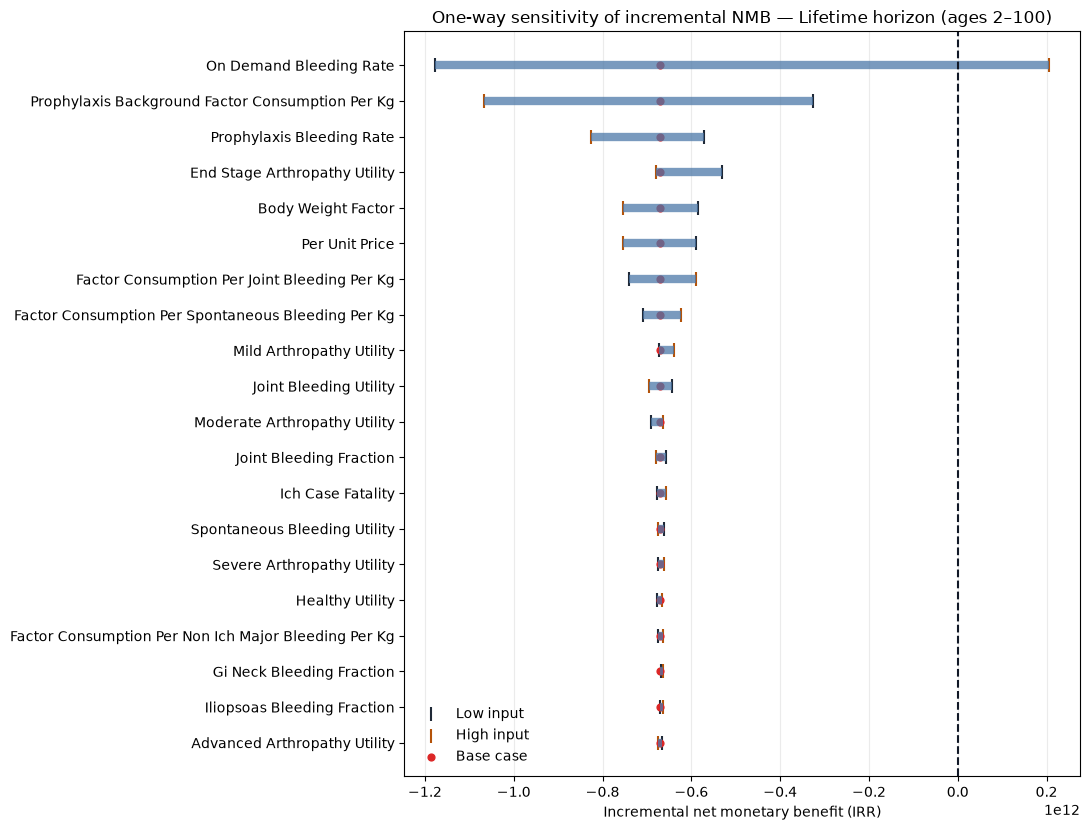

## Icer Tornado

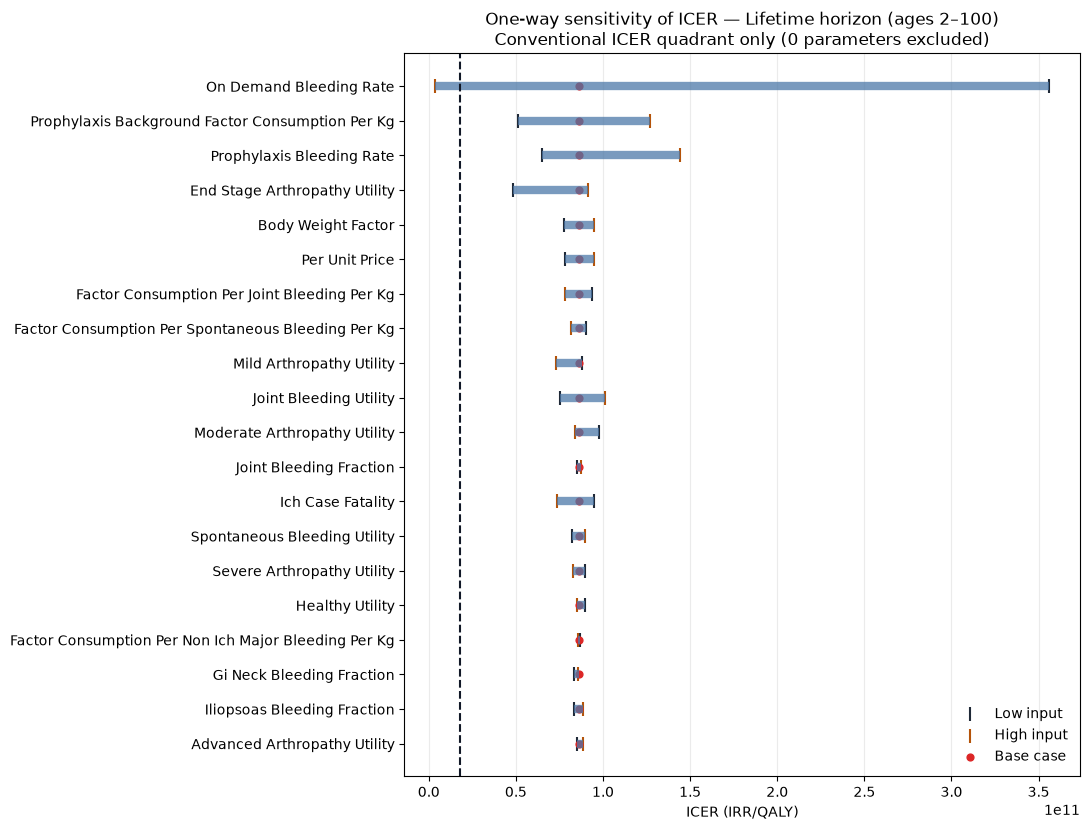

## Saved figure files

nmb_tornado: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\owsa\lifetime_age_2_100\nmb_tornado.png
icer_tornado: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\figures\owsa\lifetime_age_2_100\icer_tornado.png


In [3]:
figures = report.figures(tables=tables)
saved = report.save_figures(figures)
for title, figure in figures.items():
    display(Markdown(f"## {title.replace('_', ' ').title()}"))
    display(figure)
    plt.close(figure)

display(Markdown('## Saved figure files'))
for name, path in saved.items():
    print(f'{name}: {path}')